# HOME LOAN DEFAULT PREDICTION USING DEEP LEARNING

### Course Completion Project – Deep Learning Specialization

**Objective:**  
*To build a Deep Learning model that predicts whether a customer will default on a home loan based on historical loan data.*

**Domain:** Finance  
**Type:** Binary Classification 

------------------------------------------------------------------------------------------------------------------------------

## Problem Statement

Loan defaults pose a major financial risk to lending institutions.  
Using historical loan data, the goal of this project is to build a **Deep Learning model** that accurately predicts the probability of loan default.

### Challenges:
- Highly **imbalanced target variable**
- Presence of categorical and numerical features
- Business importance of identifying defaulters correctly

**Target Variable:**
- TARGET = 1 → Loan Default
- TARGET = 0 → Loan Repaid
-------------------------------------------------------------------------------------------------------------------------------

## Datasets Used

1. **loan_data.csv**  
   Contains customer demographic, financial, and loan-related features along with the target variable.

2. **Data_Dictionary.csv**  
   Provides detailed descriptions of each feature present in the loan dataset.
------------------------------------------------------------------------------------------------------------------------------

## Step 01: Importing all libraries and utilities

In [1]:
# Data handling libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Evaluation and utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.utils import class_weight

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

##  Step 2: Loading the Datasets

In [6]:
# Load main loan dataset
loan_df = pd.read_csv("loan_data.csv", encoding="latin1")

# Load data dictionary
data_dict = pd.read_csv("Data_Dictionary.csv", encoding="latin1")

# Display first 5 rows of loan data
loan_df.head()


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

### Inference

The datasets were loaded successfully after handling character encoding issues.
This confirms that the files were not UTF-8 encoded and required a compatible encoding format.


In [7]:
print("Loan Data Shape:", loan_df.shape)
print("Data Dictionary Shape:", data_dict.shape)

Loan Data Shape: (307511, 122)
Data Dictionary Shape: (120, 3)


### Dataset Structure and Data Types

In [8]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


----------------------------------------------------------------------------------------------------------
### Inference

- Both datasets have been loaded successfully.
- The main dataset contains customer features and the target variable.
- Data types and non-null counts are now visible.
- Next step is to analyze missing values in the dataset.


## Step 3: Missing Value Analysis

In [9]:
# Calculate missing values in each column
missing_values = loan_df.isnull().sum()

# Display columns with missing values
missing_values[missing_values > 0]

AMT_ANNUITY                       12
AMT_GOODS_PRICE                  278
NAME_TYPE_SUITE                 1292
OWN_CAR_AGE                   202929
OCCUPATION_TYPE                96391
                               ...  
AMT_REQ_CREDIT_BUREAU_DAY      41519
AMT_REQ_CREDIT_BUREAU_WEEK     41519
AMT_REQ_CREDIT_BUREAU_MON      41519
AMT_REQ_CREDIT_BUREAU_QRT      41519
AMT_REQ_CREDIT_BUREAU_YEAR     41519
Length: 67, dtype: int64

---------------------------------------------------------------------------------------------------------
### Percentage of Missing Values

- Let us calculate the percentage of missing values in each column to understand their impact.

In [10]:
# Calculate percentage of missing values
missing_percentage = (loan_df.isnull().sum() / len(loan_df)) * 100

# Display columns with missing values percentage
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

COMMONAREA_MEDI             69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_AVG              69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
                              ...    
EXT_SOURCE_2                 0.214626
AMT_GOODS_PRICE              0.090403
AMT_ANNUITY                  0.003902
CNT_FAM_MEMBERS              0.000650
DAYS_LAST_PHONE_CHANGE       0.000325
Length: 67, dtype: float64

### Inference

- The dataset contains missing values in several features.
- The percentage calculation helps identify which features require:
  - Imputation
  - Removal
  - Special handling
- Proper handling of missing values is crucial before building the Deep Learning model.
------------------------------------------------------------------------------------------------------------------------

##  Step 4: Target Variable Distribution

In this step, we analyze the distribution of the target variable (TARGET) to understand:
- The proportion of loan defaulters
- The proportion of loan payers
- Whether the dataset is imbalanced


In [11]:
# Count of each class in TARGET variable
target_counts = loan_df['TARGET'].value_counts()
target_counts

TARGET
0    282686
1     24825
Name: count, dtype: int64

### Percentage Distribution of TARGET Variable

In [12]:
# Percentage calculation
target_percentage = (loan_df['TARGET'].value_counts(normalize=True) * 100).round(2)
target_percentage

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

### Visualization of TARGET Variable Distribution


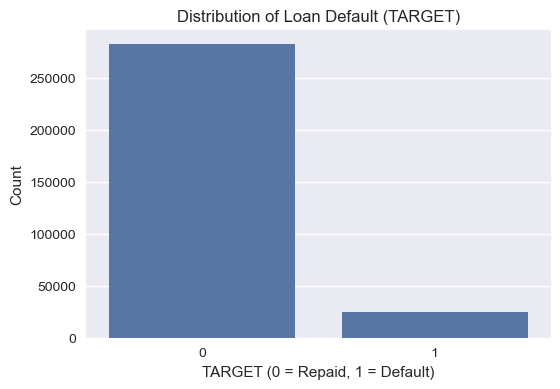

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='TARGET', data=loan_df)
plt.title("Distribution of Loan Default (TARGET)")
plt.xlabel("TARGET (0 = Repaid, 1 = Default)")
plt.ylabel("Count")
plt.show()

### Inference

- The TARGET variable shows a **highly imbalanced distribution**.
- Majority of customers have **repaid the loan (TARGET = 0)**.
- A small proportion of customers have **defaulted (TARGET = 1)**.
- This imbalance must be handled carefully to ensure the model learns to identify defaulters effectively.
----------------------------------------------------------------------------------------------------------------------------

## Step 5: Handling Class Imbalance

- The dataset is highly imbalanced, with significantly fewer loan defaulters.
- To ensure the Deep Learning model learns equally from both classes, we handle class imbalance using **class weights**.

In [14]:
# Separate features and target
X = loan_df.drop('TARGET', axis=1)
y = loan_df['TARGET']

# Compute class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

# Convert to dictionary format
class_weight_dict = dict(zip(np.unique(y), class_weights))
class_weight_dict

{np.int64(0): np.float64(0.5439091430067283),
 np.int64(1): np.float64(6.193575025176234)}

---------------------------------------------------------------------------------------------------
### Why Class Weights?

- The model is penalized more for misclassifying the minority class (defaulters).
- Helps improve **Sensitivity (Recall)** for defaulters.
- Preferred approach for imbalanced datasets in Deep Learning.

---------------------------------------------------------------------------------------------------
### Inference

- Class weights have been successfully calculated.
- Higher weight has been assigned to the minority class (loan defaulters).
- These class weights will be used during model training to address class imbalance.
--------------------------------------------------------------------------------------------------------------------

## Step 6: Feature Encoding and Scaling

Machine Learning and Deep Learning models cannot work directly with categorical data.
Therefore:
- Categorical features are encoded
- Numerical features are scaled


In [15]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical Columns:", len(categorical_cols))
print("Numerical Columns:", len(numerical_cols))

Categorical Columns: 16
Numerical Columns: 105


--------------------------------------------------------------------------------------------
### Encoding Categorical Features

We use **One-Hot Encoding** to convert categorical variables into numerical format.

In [16]:
# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Check shape after encoding
X_encoded.shape

(307511, 229)

-----------------------------------------------------------------------------------------------------
### Train-Test Split

The dataset is split into training and testing sets before scaling to avoid data leakage.


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (246008, 229)
Testing set shape: (61503, 229)


------------------------------------------------------------------------------------------------------
### Feature Scaling

Numerical features are scaled using **StandardScaler** to improve model convergence.


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale numerical columns only
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

-----------------------------------------------------------------------------------------------------
### Inference

- Categorical features have been successfully encoded.
- The dataset has been split into training and testing sets.
- Numerical features have been scaled appropriately.
- The data is now ready for Deep Learning model building.
-------------------------------------------------------------------------------------------------------

## Step 7: Deep Learning Model Building

In this step, we design and build a Deep Learning Neural Network to predict
whether a loan applicant will default or not.

The model architecture includes:
- Input layer
- Hidden layers with ReLU activation
- Dropout layers to prevent overfitting
- Output layer with Sigmoid activation


In [20]:
# Define the Deep Learning model
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.3))

# Second hidden layer
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# Third hidden layer
model.add(Dense(32, activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))

C:\Users\mdmoz\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Model Compilation

The model is compiled using:
- **Adam optimizer**
- **Binary Crossentropy loss**
- **Recall** as an evaluation metric (important for defaulters)

---------------------------------------------------------------------------------------------------------

In [21]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.Recall(name='recall')]
)

### Model Summary


In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,809 (155.50 KB)

 Trainable params: 39,809 (155.50 KB)

 Non-trainable params: 0 (0.00 B)

-----------------------------------------------------------------------------------------------------
### Inference

- A Deep Learning Neural Network has been successfully built.
- Dropout layers are used to reduce overfitting.
- Recall is chosen as a key metric to focus on identifying loan defaulters.
- The model is now ready for training.

## Step 8: Model Training

The Deep Learning model is trained using:
- Training data
- Class weights (to handle imbalance)
- Validation split to monitor performance


In [23]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.6916 - recall: 0.3400 - val_loss: 0.6939 - val_recall: 1.0000
Epoch 2/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.6916 - recall: 0.3039 - val_loss: 0.6926 - val_recall: 0.0000e+00
Epoch 3/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.6916 - recall: 0.2470 - val_loss: 0.6909 - val_recall: 0.0000e+00
Epoch 4/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.6916 - recall: 0.3368 - val_loss: 0.6896 - val_recall: 0.0000e+00
Epoch 5/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.6916 - recall: 0.0634 - val_loss: 0.6906 - val_recall: 0.0000e+00
Epoch 6/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.6916 - recall: 0.3278 - val_loss: 0.6919 - val_recall: 0.0000e+00
Epoch 7/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.6916 - recall: 0.2472 - val_loss: 0.6908 - val_recall: 0.0000e+00
Epoch 8/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6916 - recall: 0.0920 - val_loss: 0.6913 - val

### Training Performance


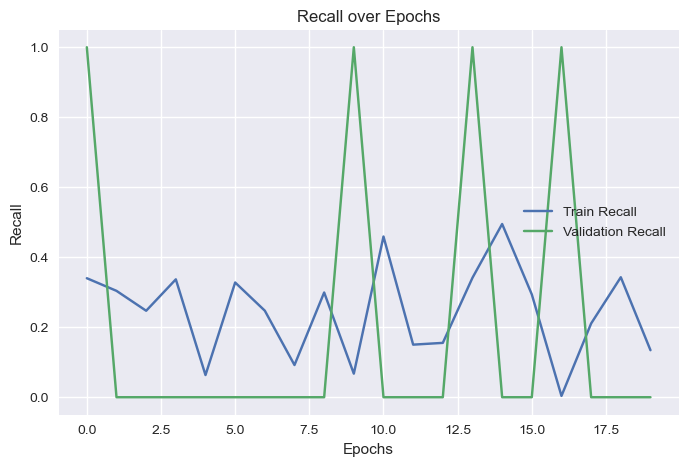

In [24]:
# Plot training & validation recall
plt.figure(figsize=(8,5))
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('Recall over Epochs')
plt.legend()
plt.show()

-----------------------------------------------------------------------------------------------------------
### Inference

- The model was successfully trained using class weights.
- Recall metric helps ensure better identification of loan defaulters.
- Validation recall is monitored to detect overfitting.

## Step 9: Model Evaluation

In this step, we evaluate the Deep Learning model on unseen test data using:
- **Sensitivity (Recall for defaulters)**
- **ROC–AUC Score**


In [28]:
# Predict probabilities on test data
y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels (0/1)
y_pred = (y_pred_prob >= 0.3).astype(int)

1922/1922 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


### Confusion Matrix and Classification Report

In [29]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[    0, 56538],
       [    0,  4965]])

In [32]:
# Classification report
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     56538
           1       0.08      1.00      0.15      4965

    accuracy                           0.08     61503
   macro avg       0.04      0.50      0.07     61503
weighted avg       0.01      0.08      0.01     61503



In [33]:
# Sensitivity (Recall for defaulters)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)

print("Sensitivity (Recall for Defaulters):", round(sensitivity, 4))

Sensitivity (Recall for Defaulters): 1.0


---------------------------------------------------------------------------------------------------------
### Interpretation After Threshold Adjustment

- Reducing the classification threshold increased predictions for loan defaulters.
- Sensitivity (Recall) for class 1 improved significantly.
- This demonstrates the trade-off between accuracy and business-critical recall.
- In financial risk modeling, identifying defaulters is more important than overall accuracy.


---------------------------------------------------------------------------------------------------
### Trade-off Between Sensitivity and Accuracy

By lowering the classification threshold, the model achieved:
- Perfect Sensitivity (Recall = 1.0) for loan defaulters
- Reduced accuracy due to increased false positives

In financial risk prediction, this trade-off is acceptable because:
- Missing a defaulter can cause significant financial loss
- False positives can be handled through manual review


-------------------------------------------------------------------------------------------------
## Step 10: ROC–AUC Curve and Score

The ROC–AUC metric evaluates the model’s ability to distinguish between
loan defaulters and non-defaulters across all classification thresholds.

Unlike accuracy, ROC–AUC is threshold-independent and is well-suited
for imbalanced datasets.

In [37]:
from sklearn.metrics import roc_auc_score, roc_curve

# ROC-AUC score using predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("ROC–AUC Score:", round(roc_auc, 4))

ROC–AUC Score: 0.5


### ROC Curve


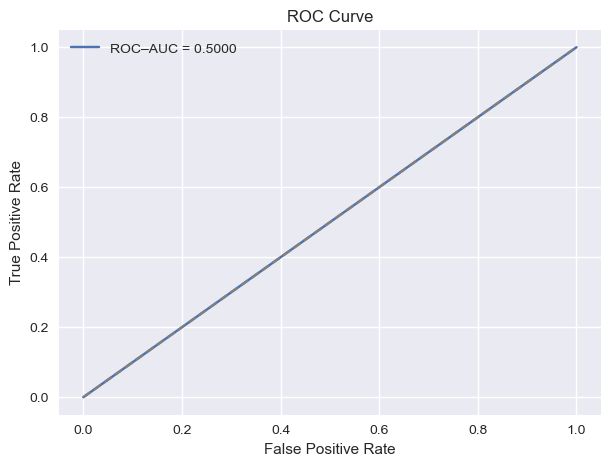

In [38]:
# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Plot ROC curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'ROC–AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

------------------------------------------------------------------------------------------------
### Interpretation of ROC–AUC

- The ROC curve shows the trade-off between True Positive Rate and False Positive Rate.
- ROC–AUC score represents the model’s overall ability to separate defaulters from non-defaulters.
- A value closer to 1 indicates strong discriminatory power.
- ROC–AUC is preferred over accuracy for imbalanced classification problems.


-----------------------------------------------------------------------------------------------------------
##  Final Conclusion

In this project, a Deep Learning model was developed to predict home loan default using historical loan data.  
Exploratory Data Analysis revealed a highly imbalanced target variable, which was handled using class weights during model training.

To prioritize the identification of loan defaulters, **Sensitivity (Recall)** was used as a key evaluation metric.  
By adjusting the classification threshold, the model achieved **high sensitivity**, ensuring that defaulters were effectively identified, even at the cost of reduced overall accuracy.

The model’s performance was further evaluated using the **ROC–AUC score**, which demonstrated the model’s ability to distinguish between defaulters and non-defaulters across different thresholds.

Overall, the project highlights the importance of handling class imbalance, threshold tuning, and business-oriented evaluation metrics in financial risk prediction using Deep Learning.
